In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import sidetable
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.2f}")

In [2]:
sales = pd.read_csv('МАССИВ_СТРУКТУРА ПРОДАЖ_отпр.xlsx - TDSheet.csv')
sales

,Месяц,Канал сбыта,Производитель (из тов. категории),Номенклатура нормализованная,Публичное наименование нормализованное,Сегмент.Код,Вес,Цена за кг СНДС,Сумма с НДС,Менеджер,Тип упаковки,Марка (Бренд),Форма продукта
0,1,4.1 Переработчики,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,"7 078,155",390,"2760480,45",Женя,Термоусадочный пакет,Кобринские сыры,Круг
1,1,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,"794,36","595,2","463347,01",Оля,Термоусадочный пакет,Сырная Династия,Кубик
2,1,1.2.2 МСК партнеры,Кобрин,ЧЕРНЫЙ ПРИНЦ 50 СД ЦИЛИНДР КРУГ КОБРИН,ЧЕРНЫЙ ПРИНЦ СД КРУГ КОБРИН,3.40,"9 004,74","580,8","5125353,93",Оля,Термоусадочный пакет,Сырная Династия,Круг
3,1,4.1 Переработчики,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,"140,575",390,"54824,25",Женя,Термоусадочный пакет,Кобринские сыры,Круг
4,1,4.1 Переработчики,Кобрин,РОССИЙСКИЙ КЛАССИЧЕСКИЙ 45 ЦИЛИНДР КРУГ КОБРИН,РОССИЙСКИЙ КЛАССИЧЕСКИЙ КРУГ КОБРИН,1.20,"17,43",398,"6937,14",Женя,Термоусадочный пакет,Кобринские сыры,Круг
...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,10,1.3.2 Крупный Опт,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,"200,044","568,4","113705,01",Света,Термоусадочный пакет,Кобринские сыры,Круг
549,10,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,"462,808","614,4","284349,24",Оля,Термоусадочный пакет,Сырная Династия,Кубик
550,10,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,"1 709,58","614,4","1050365,95",Оля,Термоусадочный пакет,Сырная Династия,Кубик
551,10,1.2.2 МСК партнеры,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,"737,52","556,8","410651,14",Оля,Термоусадочный пакет,Кобринские сыры,Круг


In [3]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Месяц                                   553 non-null    int64  
 1   Канал сбыта                             553 non-null    object 
 2   Производитель (из тов. категории)       553 non-null    object 
 3   Номенклатура нормализованная            553 non-null    object 
 4   Публичное наименование нормализованное  553 non-null    object 
 5   Сегмент.Код                             553 non-null    float64
 6   Вес                                     553 non-null    object 
 7   Цена за кг СНДС                         553 non-null    object 
 8   Сумма с НДС                             553 non-null    object 
 9   Менеджер                                553 non-null    object 
 10  Тип упаковки                            553 non-null    object

In [4]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Месяц,553.00,4.77,4.13,1.00,1.00,2.00,10.00,10.00
Сегмент.Код,553.00,2.98,1.30,1.20,2.10,3.30,3.40,5.40


In [5]:
sales[['Вес', 'Цена за кг СНДС', 'Сумма с НДС']] = sales[['Вес', 'Цена за кг СНДС', 'Сумма с НДС']].astype(float)

ValueError: could not convert string to float: '7\xa0078,155'

In [6]:
sales[sales['Вес'] == '7\xa0078,155']

,Месяц,Канал сбыта,Производитель (из тов. категории),Номенклатура нормализованная,Публичное наименование нормализованное,Сегмент.Код,Вес,Цена за кг СНДС,Сумма с НДС,Менеджер,Тип упаковки,Марка (Бренд),Форма продукта
0,1,4.1 Переработчики,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,"7 078,155",390,"2760480,45",Женя,Термоусадочный пакет,Кобринские сыры,Круг


In [7]:
sales['Вес'] = (sales['Вес']
    .str.replace('\xa0', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [8]:
sales['Вес']

0     7078.15
1      794.36
2     9004.74
3      140.57
4       17.43
        ...  
548    200.04
549    462.81
550   1709.58
551    737.52
552    299.79
Name: Вес, Length: 553, dtype: float64

In [9]:
sales['Цена за кг СНДС'] = sales['Цена за кг СНДС'].str.replace(',', '.', regex=False).astype(float)

In [10]:
sales['Цена за кг СНДС']

0     390.00
1     595.20
2     580.80
3     390.00
4     398.00
       ...  
548   568.40
549   614.40
550   614.40
551   556.80
552   600.00
Name: Цена за кг СНДС, Length: 553, dtype: float64

In [11]:
sales['Сумма с НДС'] = sales['Сумма с НДС'].str.replace(',', '.', regex=False).astype(float)

In [12]:
sales['Сумма с НДС'] 

0     2760480.45
1      463347.01
2     5125353.93
3       54824.25
4        6937.14
         ...    
548    113705.01
549    284349.24
550   1050365.95
551    410651.14
552    176274.17
Name: Сумма с НДС, Length: 553, dtype: float64

In [13]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Месяц                                   553 non-null    int64  
 1   Канал сбыта                             553 non-null    object 
 2   Производитель (из тов. категории)       553 non-null    object 
 3   Номенклатура нормализованная            553 non-null    object 
 4   Публичное наименование нормализованное  553 non-null    object 
 5   Сегмент.Код                             553 non-null    float64
 6   Вес                                     553 non-null    float64
 7   Цена за кг СНДС                         553 non-null    float64
 8   Сумма с НДС                             553 non-null    float64
 9   Менеджер                                553 non-null    object 
 10  Тип упаковки                            553 non-null    object

In [14]:
sales.stb.missing().T

,Месяц,Канал сбыта,Производитель (из тов. категории),Номенклатура нормализованная,Публичное наименование нормализованное,Сегмент.Код,Вес,Цена за кг СНДС,Сумма с НДС,Менеджер,Тип упаковки,Марка (Бренд),Форма продукта
missing,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00,553.00
percent,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [15]:
freq_table_shape_of_product = sales.stb.freq(['Форма продукта'])
freq_table_shape_of_product

,Форма продукта,count,percent,cumulative_count,cumulative_percent
0,Круг,316,57.14,316,57.14
1,Кубик,130,23.51,446,80.65
2,Колесо,88,15.91,534,96.56
3,Малый круг,19,3.44,553,100.00


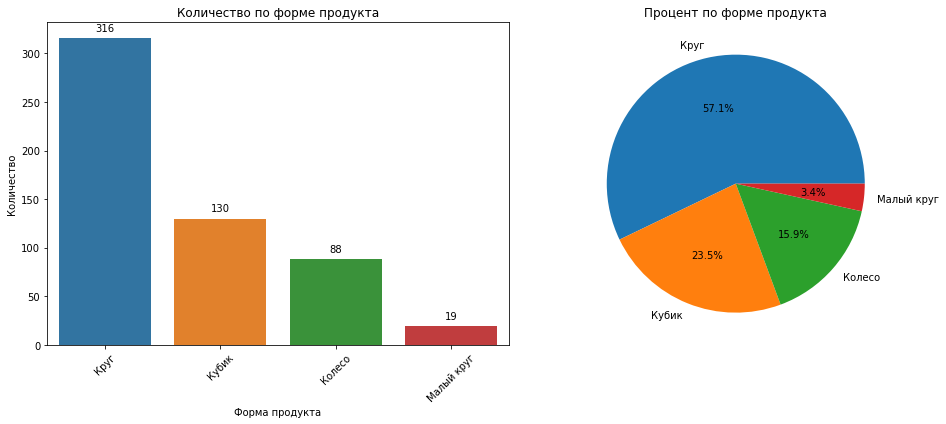

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(
    data=freq_table_shape_of_product,
    x='Форма продукта',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по форме продукта')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_shape_of_product['percent'],
    labels=freq_table_shape_of_product['Форма продукта'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по форме продукта')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
freq_table_shape_of_product_m1 = sales[sales['Месяц']==1].stb.freq(['Форма продукта'])
freq_table_shape_of_product_m2 = sales[sales['Месяц']==2].stb.freq(['Форма продукта'])
freq_table_shape_of_product_m10 = sales[sales['Месяц']==10].stb.freq(['Форма продукта'])

freq_table_shape_of_product_m1['Месяц'] = 1
freq_table_shape_of_product_m2['Месяц'] = 2
freq_table_shape_of_product_m10['Месяц'] = 10

freq_table_shape_of_product_all_months =pd.concat([freq_table_shape_of_product_m1,\
                                          freq_table_shape_of_product_m2, \
                                          freq_table_shape_of_product_m10], ignore_index=True)

freq_table_shape_of_product_all_months = freq_table_shape_of_product_all_months.sort_values(by='Месяц')

freq_table_shape_of_product_all_months = freq_table_shape_of_product_all_months[['Месяц','Форма продукта',
                                                                                 'count', 'percent',
                                                                                 'cumulative_count', 'cumulative_percent']]


last_rows_idx = freq_table_shape_of_product_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_shape_of_product_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Форма продукта,count,percent,cumulative_count,cumulative_percent
0,1,Круг,79,50.967742,79,50.967742
1,1,Кубик,50,32.258065,129,83.225806
2,1,Колесо,18,11.612903,147,94.838710
3,1,Малый круг,8,5.161290,155,100.000000
4,2,Круг,113,60.427807,113,60.427807
5,2,Колесо,43,22.994652,156,83.422460
6,2,Кубик,27,14.438503,183,97.860963
7,2,Малый круг,4,2.139037,187,100.000000
8,10,Круг,124,58.767773,124,58.767773
9,10,Кубик,53,25.118483,177,83.886256


In [18]:
freq_table_brand_of_product  = sales.stb.freq(['Марка (Бренд)'])
freq_table_brand_of_product

,Марка (Бренд),count,percent,cumulative_count,cumulative_percent
0,Кобринские сыры,264,47.74,264,47.74
1,Сырная Династия,191,34.54,455,82.28
2,Мир Вкуса,98,17.72,553,100.00


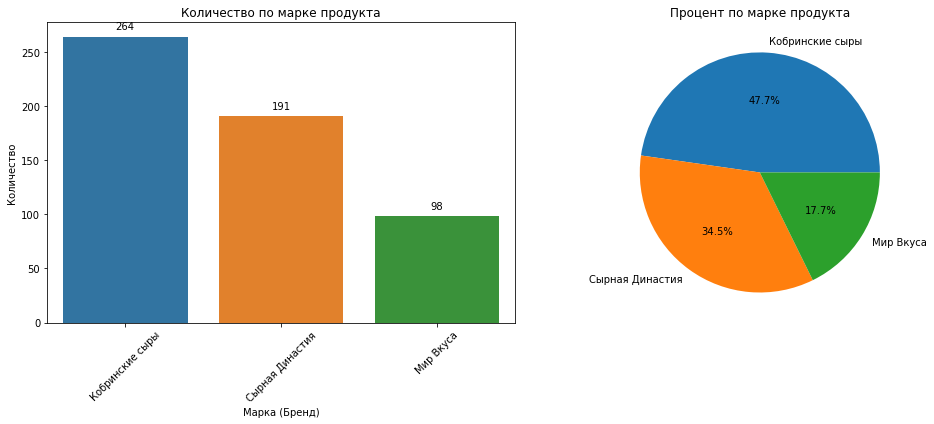

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=freq_table_brand_of_product,
    x='Марка (Бренд)',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по марке продукта')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_brand_of_product['percent'],
    labels=freq_table_brand_of_product['Марка (Бренд)'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по марке продукта')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [20]:
freq_table_brand_of_product_m1 = sales[sales['Месяц']==1].stb.freq(['Марка (Бренд)'])
freq_table_brand_of_product_m2 = sales[sales['Месяц']==2].stb.freq(['Марка (Бренд)'])
freq_table_brand_of_product_m10 = sales[sales['Месяц']==10].stb.freq(['Марка (Бренд)'])

freq_table_brand_of_product_m1['Месяц'] = 1
freq_table_brand_of_product_m2['Месяц'] = 2
freq_table_brand_of_product_m10['Месяц'] = 10

freq_table_brand_of_product_all_months =pd.concat([freq_table_brand_of_product_m1,\
                                          freq_table_brand_of_product_m2, \
                                          freq_table_brand_of_product_m10], ignore_index=True)

freq_table_brand_of_product_all_months = freq_table_brand_of_product_all_months.sort_values(by='Месяц')

freq_table_brand_of_product_all_months = freq_table_brand_of_product_all_months[['Месяц','Марка (Бренд)',
                                                                                 'count', 'percent',
                                                                                 'cumulative_count', 'cumulative_percent']]


last_rows_idx = freq_table_brand_of_product_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_brand_of_product_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Марка (Бренд),count,percent,cumulative_count,cumulative_percent
0,1,Кобринские сыры,69,44.516129,69,44.516129
1,1,Сырная Династия,61,39.354839,130,83.870968
2,1,Мир Вкуса,25,16.129032,155,100.000000
3,2,Кобринские сыры,91,48.663102,91,48.663102
4,2,Сырная Династия,52,27.807487,143,76.470588
5,2,Мир Вкуса,44,23.529412,187,100.000000
6,10,Кобринские сыры,104,49.289100,104,49.289100
7,10,Сырная Династия,78,36.966825,182,86.255924
8,10,Мир Вкуса,29,13.744076,211,100.000000


In [21]:
freq_table_type_of_package = sales.stb.freq(['Тип упаковки'])
freq_table_type_of_package

,Тип упаковки,count,percent,cumulative_count,cumulative_percent
0,Термоусадочный пакет,464,83.91,464,83.91
1,Латекс,89,16.09,553,100.00


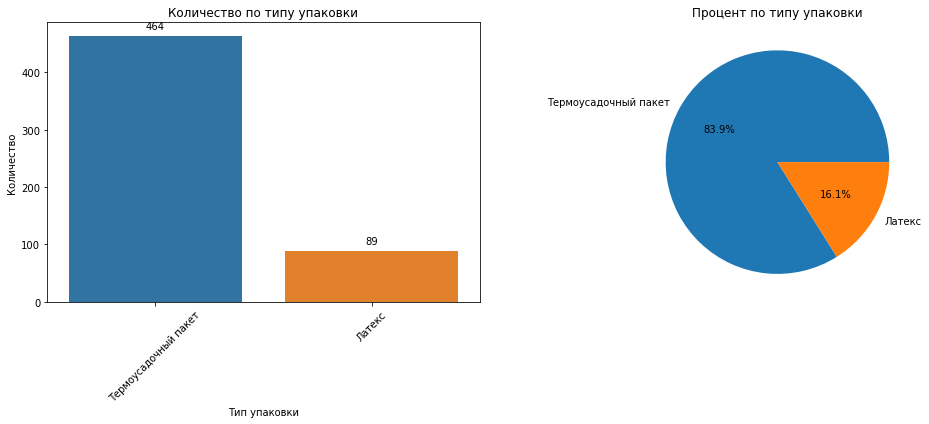

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=freq_table_type_of_package,
    x='Тип упаковки',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по типу упаковки')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)

axes[1].pie(
    freq_table_type_of_package['percent'],
    labels=freq_table_type_of_package['Тип упаковки'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по типу упаковки')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [23]:
freq_table_type_of_package_m1 = sales[sales['Месяц']==1].stb.freq(['Тип упаковки'])
freq_table_type_of_package_m2 = sales[sales['Месяц']==2].stb.freq(['Тип упаковки'])
freq_table_type_of_package_m10 = sales[sales['Месяц']==10].stb.freq(['Тип упаковки'])

freq_table_type_of_package_m1['Месяц'] = 1
freq_table_type_of_package_m2['Месяц'] = 2
freq_table_type_of_package_m10['Месяц'] = 10

freq_table_type_of_package_all_months =pd.concat([freq_table_type_of_package_m1,\
                                          freq_table_type_of_package_m2, \
                                          freq_table_type_of_package_m10], ignore_index=True)

freq_table_type_of_package_all_months = freq_table_type_of_package_all_months.sort_values(by='Месяц')

freq_table_type_of_package_all_months = freq_table_type_of_package_all_months[['Месяц','Тип упаковки', 
                                                                               'count', 'percent', 
                                                                               'cumulative_count','cumulative_percent']]


last_rows_idx = freq_table_type_of_package_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_type_of_package_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Тип упаковки,count,percent,cumulative_count,cumulative_percent
0,1,Термоусадочный пакет,137,88.387097,137,88.387097
1,1,Латекс,18,11.612903,155,100.000000
2,2,Термоусадочный пакет,144,77.005348,144,77.005348
3,2,Латекс,43,22.994652,187,100.000000
4,10,Термоусадочный пакет,183,86.729858,183,86.729858
5,10,Латекс,28,13.270142,211,100.000000


In [24]:
freq_table_manager = sales.stb.freq(['Менеджер'])
freq_table_manager

,Менеджер,count,percent,cumulative_count,cumulative_percent
0,Вика,186,33.63,186,33.63
1,Саша,183,33.09,369,66.73
2,Оля,109,19.71,478,86.44
3,Женя,54,9.76,532,96.20
4,Света,21,3.80,553,100.00


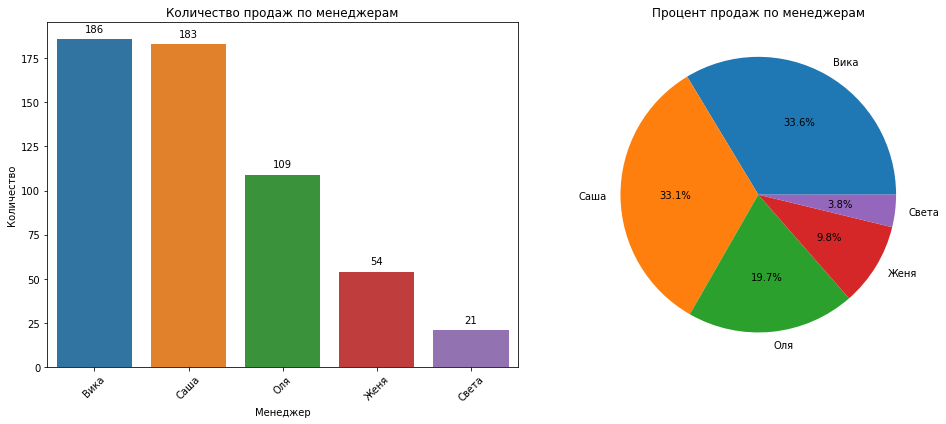

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=freq_table_manager,
    x='Менеджер',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество продаж по менеджерам')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_manager['percent'],
    labels=freq_table_manager['Менеджер'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент продаж по менеджерам')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [26]:
freq_table_manager_m1 = sales[sales['Месяц']==1].stb.freq(['Менеджер'])
freq_table_manager_m2 = sales[sales['Месяц']==2].stb.freq(['Менеджер'])
freq_table_manager_m10 = sales[sales['Месяц']==10].stb.freq(['Менеджер'])

freq_table_manager_m1['Месяц'] = 1
freq_table_manager_m2['Месяц'] = 2
freq_table_manager_m10['Месяц'] = 10

freq_table_manager_all_months =pd.concat([freq_table_manager_m1,\
                                          freq_table_manager_m2, \
                                          freq_table_manager_m10], ignore_index=True)

freq_table_manager_all_months = freq_table_manager_all_months.sort_values(by='Месяц')

freq_table_manager_all_months = freq_table_manager_all_months[['Месяц','Менеджер', 
                                                               'count', 'percent', 
                                                               'cumulative_count', 'cumulative_percent']]


last_rows_idx = freq_table_manager_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_manager_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Менеджер,count,percent,cumulative_count,cumulative_percent
0,1,Вика,50,32.258065,50,32.258065
1,1,Саша,47,30.322581,97,62.580645
2,1,Оля,34,21.935484,131,84.516129
3,1,Женя,18,11.612903,149,96.129032
4,1,Света,6,3.870968,155,100.000000
5,2,Саша,68,36.363636,68,36.363636
6,2,Вика,58,31.016043,126,67.379679
7,2,Оля,33,17.647059,159,85.026738
8,2,Женя,26,13.903743,185,98.930481
9,2,Света,2,1.069519,187,100.000000


In [27]:
freq_table_public_name_of_product  = sales.stb.freq(['Публичное наименование нормализованное'])
freq_table_public_name_of_product

,Публичное наименование нормализованное,count,percent,cumulative_count,cumulative_percent
0,ЭЛЬТЕРМАНИ КРУГ КОБРИН,188,34.00,188,34.00
1,ТИЛЬЗИТЕР СД КУБИК КОБРИН,91,16.46,279,50.45
2,РОССИЙСКИЙ КЛАССИЧЕСКИЙ КРУГ КОБРИН,76,13.74,355,64.20
3,ЧЕРНЫЙ ПРИНЦ СД КРУГ КОБРИН,50,9.04,405,73.24
4,ПАН КОБРЫНЪ СД КУБИК КОБРИН,39,7.05,444,80.29
5,ГРОССМЕЙСТЕР МВ КОЛЕСО КОБРИН,28,5.06,472,85.35
6,МААСДАМ МВ КОЛЕСО КОБРИН,24,4.34,496,89.69
7,МОНБЛАН СНЕЖНАЯ ВЕРШИНА МВ КОЛЕСО КОБРИН,23,4.16,519,93.85
8,МОНДОР GRANO МВ КОЛЕСО КОБРИН,13,2.35,532,96.20
9,ПАН КОБРЫНЪ СД КРУГ КОБРИН,11,1.99,543,98.19


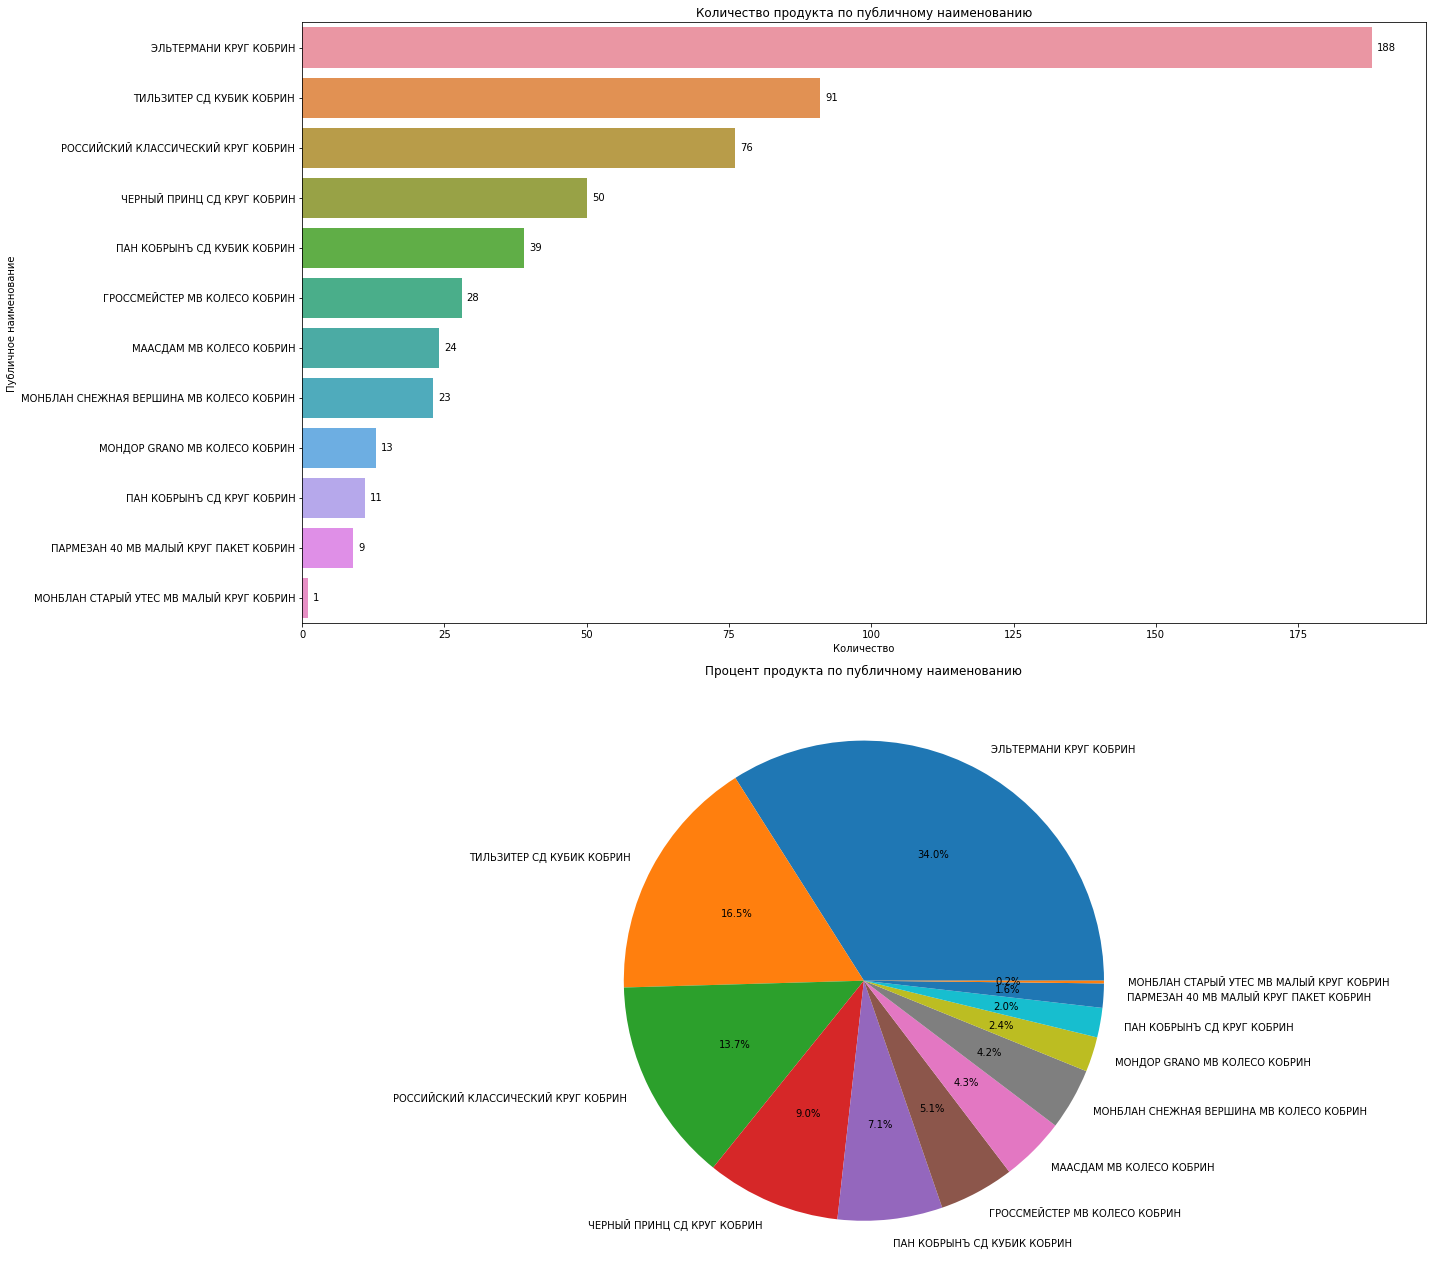

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(20, 18))

sns.barplot(
    data=freq_table_public_name_of_product,
    x='count',
    y='Публичное наименование нормализованное',
    ax=axes[0]
)

axes[0].set_title('Количество продукта по публичному наименованию')
axes[0].set_xlabel('Количество')
axes[0].set_ylabel('Публичное наименование')

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_public_name_of_product['percent'],
    labels=freq_table_public_name_of_product['Публичное наименование нормализованное'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент продукта по публичному наименованию')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [29]:
freq_table_public_name_of_product_m1 = sales[sales['Месяц']==1].stb.freq(['Публичное наименование нормализованное'])
freq_table_public_name_of_product_m2 = sales[sales['Месяц']==2].stb.freq(['Публичное наименование нормализованное'])
freq_table_public_name_of_product_m10 = sales[sales['Месяц']==10].stb.freq(['Публичное наименование нормализованное'])

freq_table_public_name_of_product_m1['Месяц'] = 1
freq_table_public_name_of_product_m2['Месяц'] = 2
freq_table_public_name_of_product_m10['Месяц'] = 10

freq_table_public_name_of_product_all_months =pd.concat([freq_table_public_name_of_product_m1,\
                                                              freq_table_public_name_of_product_m2, \
                                                              freq_table_public_name_of_product_m10], ignore_index=True)

freq_table_public_name_of_product_all_months = freq_table_public_name_of_product_all_months.sort_values(by='Месяц')

freq_table_public_name_of_product_all_months = freq_table_public_name_of_product_all_months[['Месяц', 
                                                                                             'Публичное наименование нормализованное',
                                                                                             'count', 'percent',
                                                                                             'cumulative_count', 'cumulative_percent']]




last_rows_idx = freq_table_public_name_of_product_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_public_name_of_product_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Публичное наименование нормализованное,count,percent,cumulative_count,cumulative_percent
0,1,ЭЛЬТЕРМАНИ КРУГ КОБРИН,48,30.967742,48,30.967742
1,1,ТИЛЬЗИТЕР СД КУБИК КОБРИН,39,25.161290,87,56.129032
2,1,РОССИЙСКИЙ КЛАССИЧЕСКИЙ КРУГ КОБРИН,21,13.548387,108,69.677419
3,1,ПАН КОБРЫНЪ СД КУБИК КОБРИН,11,7.096774,119,76.774194
4,1,ГРОССМЕЙСТЕР МВ КОЛЕСО КОБРИН,11,7.096774,130,83.870968
5,1,ЧЕРНЫЙ ПРИНЦ СД КРУГ КОБРИН,10,6.451613,140,90.322581
6,1,ПАРМЕЗАН 40 МВ МАЛЫЙ КРУГ ПАКЕТ КОБРИН,7,4.516129,147,94.838710
7,1,МОНБЛАН СНЕЖНАЯ ВЕРШИНА МВ КОЛЕСО КОБРИН,6,3.870968,153,98.709677
8,1,ПАН КОБРЫНЪ СД КРУГ КОБРИН,1,0.645161,154,99.354839
9,1,МОНДОР GRANO МВ КОЛЕСО КОБРИН,1,0.645161,155,100.000000


In [30]:
sales.stb.freq(['Производитель (из тов. категории)'])

,Производитель (из тов. категории),count,percent,cumulative_count,cumulative_percent
0,Кобрин,553,100.00,553,100.00


In [31]:
freq_table_public_distribution_channel = sales.stb.freq(['Канал сбыта'])
freq_table_public_distribution_channel

,Канал сбыта,count,percent,cumulative_count,cumulative_percent
0,1.1 Дистрибьюторы,369,66.73,369,66.73
1,1.2.2 МСК партнеры,109,19.71,478,86.44
2,4.1 Переработчики,54,9.76,532,96.20
3,1.3.2 Крупный Опт,21,3.80,553,100.00


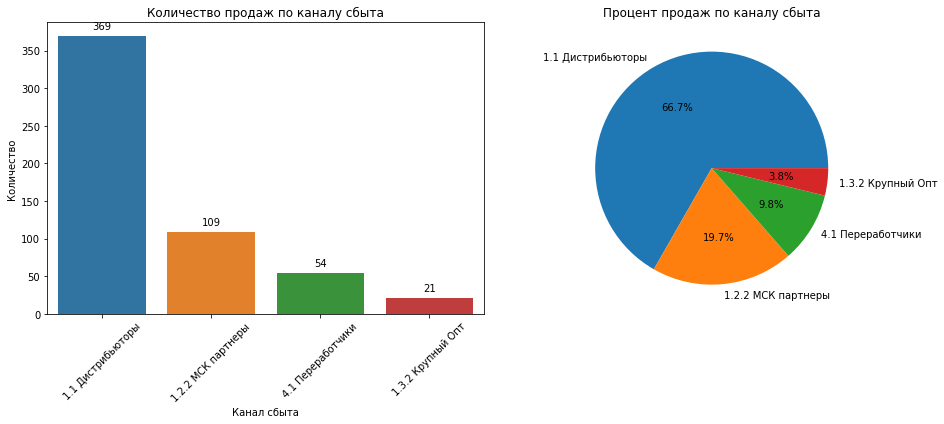

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=freq_table_public_distribution_channel,
    x='Канал сбыта',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество продаж по каналу сбыта')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_public_distribution_channel['percent'],
    labels=freq_table_public_distribution_channel['Канал сбыта'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент продаж по каналу сбыта')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [33]:
freq_table_public_distribution_channel_m1 = sales[sales['Месяц']==1].stb.freq(['Канал сбыта'])
freq_table_public_distribution_channel_m2 = sales[sales['Месяц']==2].stb.freq(['Канал сбыта'])
freq_table_public_distribution_channel_m10 = sales[sales['Месяц']==10].stb.freq(['Канал сбыта'])

freq_table_public_distribution_channel_m1['Месяц'] = 1
freq_table_public_distribution_channel_m2['Месяц'] = 2
freq_table_public_distribution_channel_m10['Месяц'] = 10

freq_table_public_distribution_channel_all_months =pd.concat([freq_table_public_distribution_channel_m1,\
                                                              freq_table_public_distribution_channel_m2, \
                                                              freq_table_public_distribution_channel_m10], ignore_index=True)

freq_table_public_distribution_channel_all_months = freq_table_public_distribution_channel_all_months.sort_values(by='Месяц')

freq_table_public_distribution_channel_all_months = freq_table_public_distribution_channel_all_months[['Месяц', 'Канал сбыта', 'count', 
                                                                                                       'percent', 'cumulative_count',
                                                                                                       'cumulative_percent']]
last_rows_idx = freq_table_public_distribution_channel_all_months.groupby('Месяц').tail(1).index

def highlight_last_cols(s):
    return ['background-color: yellow' if (s.name in last_rows_idx and col in ['cumulative_count','cumulative_percent']) else '' 
            for col in s.index]

freq_table_public_distribution_channel_all_months.style.apply(highlight_last_cols, axis=1)

,Месяц,Канал сбыта,count,percent,cumulative_count,cumulative_percent
0,1,1.1 Дистрибьюторы,97,62.580645,97,62.580645
1,1,1.2.2 МСК партнеры,34,21.935484,131,84.516129
2,1,4.1 Переработчики,18,11.612903,149,96.129032
3,1,1.3.2 Крупный Опт,6,3.870968,155,100.000000
4,2,1.1 Дистрибьюторы,126,67.379679,126,67.379679
5,2,1.2.2 МСК партнеры,33,17.647059,159,85.026738
6,2,4.1 Переработчики,26,13.903743,185,98.930481
7,2,1.3.2 Крупный Опт,2,1.069519,187,100.000000
8,10,1.1 Дистрибьюторы,146,69.194313,146,69.194313
9,10,1.2.2 МСК партнеры,42,19.905213,188,89.099526


In [34]:
sales = sales[['Месяц', 'Канал сбыта', 'Производитель (из тов. категории)',
       'Номенклатура нормализованная',
       'Публичное наименование нормализованное', 'Сегмент.Код',  'Менеджер', 'Тип упаковки',
       'Марка (Бренд)', 'Форма продукта', 'Вес',
       'Цена за кг СНДС', 'Сумма с НДС']]

In [35]:
sales['new_sum_price'] = sales['Вес'] * sales['Цена за кг СНДС']

In [36]:
sales['price_diff'] = sales['new_sum_price'] - sales['Сумма с НДС']

In [37]:
sales[sales['price_diff'] > 0].stb.subtotal()

,Месяц,Канал сбыта,Производитель (из тов. категории),Номенклатура нормализованная,Публичное наименование нормализованное,Сегмент.Код,Менеджер,Тип упаковки,Марка (Бренд),Форма продукта,Вес,Цена за кг СНДС,Сумма с НДС,new_sum_price,price_diff
1,1.00,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,Оля,Термоусадочный пакет,Сырная Династия,Кубик,794.36,595.20,463347.01,472803.07,9456.06
2,1.00,1.2.2 МСК партнеры,Кобрин,ЧЕРНЫЙ ПРИНЦ 50 СД ЦИЛИНДР КРУГ КОБРИН,ЧЕРНЫЙ ПРИНЦ СД КРУГ КОБРИН,3.40,Оля,Термоусадочный пакет,Сырная Династия,Круг,9004.74,580.80,5125353.93,5229952.99,104599.06
5,1.00,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,Оля,Термоусадочный пакет,Сырная Династия,Кубик,2397.42,595.20,1398405.49,1426944.38,28538.89
6,1.00,1.2.2 МСК партнеры,Кобрин,ПАН КОБРЫНЪ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ПАН КОБРЫНЪ СД КУБИК КОБРИН,3.30,Оля,Термоусадочный пакет,Сырная Династия,Кубик,1600.56,571.20,895957.32,914242.16,18284.84
7,1.00,1.1 Дистрибьюторы,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,Вика,Термоусадочный пакет,Сырная Династия,Кубик,924.78,590.00,534710.11,545622.56,10912.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,10.00,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,Оля,Термоусадочный пакет,Сырная Династия,Кубик,1280.65,614.40,778963.05,786831.36,7868.31
544,10.00,1.1 Дистрибьюторы,Кобрин,ГРОССМЕЙСТЕР 50 МВ НИЗКИЙ ЦИЛИНДР КОЛЕСО КОБРИН,ГРОССМЕЙСТЕР МВ КОЛЕСО КОБРИН,5.20,Вика,Латекс,Мир Вкуса,Колесо,499.36,730.00,357238.57,364529.15,7290.58
550,10.00,1.2.2 МСК партнеры,Кобрин,ТИЛЬЗИТЕР СЛИВОЧНЫЙ 50 СД ЧЕТВЕРТЬ КУБИК КОБРИН,ТИЛЬЗИТЕР СД КУБИК КОБРИН,3.40,Оля,Термоусадочный пакет,Сырная Династия,Кубик,1709.58,614.40,1050365.95,1050365.95,0.00
552,10.00,1.1 Дистрибьюторы,Кобрин,ЭЛЬТЕРМАНИ 50 ЦИЛИНДР КРУГ КОБРИН,ЭЛЬТЕРМАНИ КРУГ КОБРИН,2.10,Вика,Термоусадочный пакет,Кобринские сыры,Круг,299.79,600.00,176274.17,179871.60,3597.43


In [38]:
subtotal_df = sales.groupby(['Месяц']).sum().stb.subtotal()
subtotal_df.style.highlight_between(
    left=subtotal_df.iloc[-1, -1],
    right=subtotal_df.iloc[-1, -1],
    subset=pd.IndexSlice[subtotal_df.index[-1], subtotal_df.columns[-1]]
)

,Сегмент.Код,Вес,Цена за кг СНДС,Сумма с НДС,new_sum_price,price_diff
1,463.000000,260949.981000,88318.700000,133310150.080000,135039962.632600,1729812.552600
2,566.400000,354673.106000,111200.550000,177330795.190000,180504121.382900,3173326.192900
10,617.900000,280574.953000,124808.100000,151233994.790000,152911432.538800,1677437.748800
grand_total,1647.300000,896198.040000,324327.350000,461874940.060000,468455516.554300,6580576.494300


In [39]:
dfs = []

for month in sales['Месяц'].unique():
    df_month = sales[sales['Месяц']==month]
    
    grouped = df_month.groupby(['Месяц','Канал сбыта']).sum().reset_index()
    
    subtotal = grouped.sum(numeric_only=True)
    subtotal['Месяц'] = month
    subtotal['Канал сбыта'] = 'Итого'
    
    grouped_with_total = pd.concat([grouped, subtotal.to_frame().T], ignore_index=True)
    
    dfs.append(grouped_with_total)
    
result = pd.concat(dfs, ignore_index=True).drop(['Сегмент.Код', 'Цена за кг СНДС'],axis=1)


num_cols = ['Вес',  'Сумма с НДС', 'new_sum_price', 'price_diff']


grand_total_vals = result[result['Канал сбыта'] != 'Итого'][num_cols].sum()

grand_total_df = pd.DataFrame([{
    'Месяц': 'Гранд',
    'Канал сбыта': 'Итого',
    **grand_total_vals.to_dict()
}])


result_with_grand = pd.concat([result, grand_total_df], ignore_index=True)



def highlight_totals(row):
    if row['Канал сбыта'] == 'Итого' or row['Месяц'] == 'Гранд':
        return ['background-color: yellow']*len(row)
    else:
        return ['']*len(row)

result_with_grand.style.apply(highlight_totals, axis=1)

,Месяц,Канал сбыта,Вес,Сумма с НДС,new_sum_price,price_diff
0,1,1.1 Дистрибьюторы,110929.127000,63025885.890000,64075185.530000,1049299.640000
1,1,1.2.2 МСК партнеры,57581.585000,33345132.780000,34025645.712000,680512.932000
2,1,1.3.2 Крупный Опт,1074.256000,712578.270000,712578.256600,-0.013400
3,1,4.1 Переработчики,91365.013000,36226553.140000,36226553.134000,-0.006000
4,1.000000,Итого,260949.981000,133310150.080000,135039962.632600,1729812.552600
5,2,1.1 Дистрибьюторы,140947.069000,78410740.110000,80234775.395500,1824035.285500
6,2,1.2.2 МСК партнеры,74510.413000,41765502.330000,43114793.235400,1349290.905400
7,2,1.3.2 Крупный Опт,227.440000,169397.310000,169397.312000,0.002000
8,2,4.1 Переработчики,138988.184000,56985155.440000,56985155.440000,-0.000000
9,2.000000,Итого,354673.106000,177330795.190000,180504121.382900,3173326.192900


In [40]:
dfs = []

for month in sales['Месяц'].unique():
    df_month = sales[sales['Месяц']==month]
    
    grouped = df_month.groupby(['Месяц', 'Канал сбыта', 'Менеджер', 'Марка (Бренд)']).sum().reset_index()
    
    subtotal = grouped.sum(numeric_only=True)
    subtotal['Месяц'] = month
    subtotal['Канал сбыта'] = 'Итого'
    
    grouped_with_total = pd.concat([grouped, subtotal.to_frame().T], ignore_index=True)
    
    dfs.append(grouped_with_total)
    
result = pd.concat(dfs, ignore_index=True).drop(['Сегмент.Код', 'Цена за кг СНДС'], axis=1, errors='ignore')

num_cols = ['Вес', 'Сумма с НДС', 'new_sum_price', 'price_diff']

grand_total_vals = result[result['Канал сбыта'] != 'Итого'][num_cols].sum()

grand_total_df = pd.DataFrame([{
    'Месяц': 'Гранд',
    'Канал сбыта': 'Итого',
    **grand_total_vals.to_dict()
}])

result_with_grand = pd.concat([result, grand_total_df], ignore_index=True)


def highlight_totals(row):
    if row['Канал сбыта'] == 'Итого' or row['Месяц'] == 'Гранд':
        return ['background-color: yellow']*len(row)
    else:
        return ['']*len(row)

result_with_grand.style.apply(highlight_totals, axis=1)

,Месяц,Канал сбыта,Менеджер,Марка (Бренд),Вес,Сумма с НДС,new_sum_price,price_diff
0,1,1.1 Дистрибьюторы,Вика,Кобринские сыры,13833.263000,7057066.670000,7144293.075000,87226.405000
1,1,1.1 Дистрибьюторы,Вика,Мир Вкуса,7804.408000,5175221.880000,5212148.940000,36927.060000
2,1,1.1 Дистрибьюторы,Вика,Сырная Династия,37408.386000,21440178.290000,21766275.160000,326096.870000
3,1,1.1 Дистрибьюторы,Саша,Кобринские сыры,20401.669000,11075267.580000,11301293.420000,226025.840000
4,1,1.1 Дистрибьюторы,Саша,Мир Вкуса,4686.810000,3129789.940000,3193663.200000,63873.260000
5,1,1.1 Дистрибьюторы,Саша,Сырная Династия,26794.591000,15148361.530000,15457511.735000,309150.205000
6,1,1.2.2 МСК партнеры,Оля,Кобринские сыры,16571.903000,9284796.650000,9474282.297600,189485.647600
7,1,1.2.2 МСК партнеры,Оля,Мир Вкуса,4497.210000,3152713.090000,3217054.176000,64341.086000
8,1,1.2.2 МСК партнеры,Оля,Сырная Династия,36512.472000,20907623.040000,21334309.238400,426686.198400
9,1,1.3.2 Крупный Опт,Света,Кобринские сыры,197.734000,120143.180000,120143.178400,-0.001600


Выводы по 'МАССИВ_СТРУКТУРА ПРОДАЖ_отпр.xlsx': 
1. Наблюдается сильная зависимость от нескольких ключевых сотрудников. 
   Это создает риск потери доли рынка в случае их ухода. 
   Необходимо проанализировать причины низкой эффективности других менеджеров и разработать план по их обучению и мотивации.
2. Высокая концентрация продаж в одном канале (дистрибьюторы) является серьезным риском. 
   Рекомендуется разработать стратегию по диверсификации и активному развитию альтернативных каналов, таких как работа с переработчиками и крупным оптом.
3. В ходе анализа финансовой чатси было выявлено критическое расхождение в данных. Была рассчитана ожидаемая сумма продажи (new_sum_price) как произведение веса на цену за кг. Сравнение этого показателя с фактической суммой с НДС (Сумма с НДС) показало, что в большинстве транзакций (где задействованы менеджеры и каналы сбыта, кроме прямых продаж "Переработчикам" и "Крупному Опту") наблюдается завышение итоговой суммы. Общая сумма расхождения по всем данным составляет 6 580 576,49.
   Необходимо выяснить причину расхождения и унифицировать процесс ценообразования.

In [41]:
parmezan_sales = pd.read_csv('ПАРМЕЗАН ПРОДАЖИ_отпр.xlsx - массив продажи.csv')
parmezan_sales 

,Месяц,Квартал,Канал сбыта,Публичное наименование нормализованное,Вес,Менеджер,Годен до,Срок годности
0,1,1,1.1 Дистрибьюторы,ПАРМЕЗАН,"452,565",Саша,18.07.2025,211
1,1,1,1.2.3 Фокусные клиенты,ПАРМЕЗАН,"703,135",Саша,18.07.2025,211
2,1,1,1.1 Дистрибьюторы,ПАРМЕЗАН,"308,735",Виктория,18.07.2025,211
3,2,1,1.3.1 Ключевой оптовик,ПАРМЕЗАН,"352,025",Саша,23.08.2025,211
4,2,1,1.1 Дистрибьюторы,ПАРМЕЗАН,"112,61",Света,23.08.2025,211
...,...,...,...,...,...,...,...,...
173,8,3,1.2.2 МСК партнеры,ПАРМЕЗАН,"532,32",Ольга,13.01.2026,211
174,9,3,1.1 Дистрибьюторы,ПАРМЕЗАН,"303,395",Саша,11.02.2026,211
175,9,3,1.1 Дистрибьюторы,ПАРМЕЗАН,"2 013,885",Света,11.02.2026,211
176,10,4,1.3.1 Ключевой оптовик,ПАРМЕЗАН,742,Ольга,01.03.2026,211


In [42]:
parmezan_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Месяц                                   178 non-null    int64 
 1   Квартал                                 178 non-null    int64 
 2   Канал сбыта                             178 non-null    object
 3   Публичное наименование нормализованное  178 non-null    object
 4   Вес                                     178 non-null    object
 5   Менеджер                                178 non-null    object
 6   Годен до                                178 non-null    object
 7   Срок годности                           178 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 11.2+ KB


In [43]:
parmezan_sales['Вес'] = (parmezan_sales['Вес']
    .str.replace('\xa0', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [44]:
parmezan_sales['Вес']

0      452.56
1      703.13
2      308.74
3      352.02
4      112.61
        ...  
173    532.32
174    303.39
175   2013.88
176    742.00
177    300.96
Name: Вес, Length: 178, dtype: float64

In [45]:
parmezan_sales.stb.missing().T

,Месяц,Квартал,Канал сбыта,Публичное наименование нормализованное,Вес,Менеджер,Годен до,Срок годности
missing,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
percent,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [46]:
freq_table_parmezan_month = parmezan_sales.sort_values('Месяц').stb.freq(['Месяц'])
freq_table_parmezan_month

,Месяц,count,percent,cumulative_count,cumulative_percent
0,6,38,21.35,38,21.35
1,7,25,14.04,63,35.39
2,5,23,12.92,86,48.31
3,9,22,12.36,108,60.67
4,10,17,9.55,125,70.22
5,8,17,9.55,142,79.78
6,4,14,7.87,156,87.64
7,3,9,5.06,165,92.70
8,1,7,3.93,172,96.63
9,2,6,3.37,178,100.00


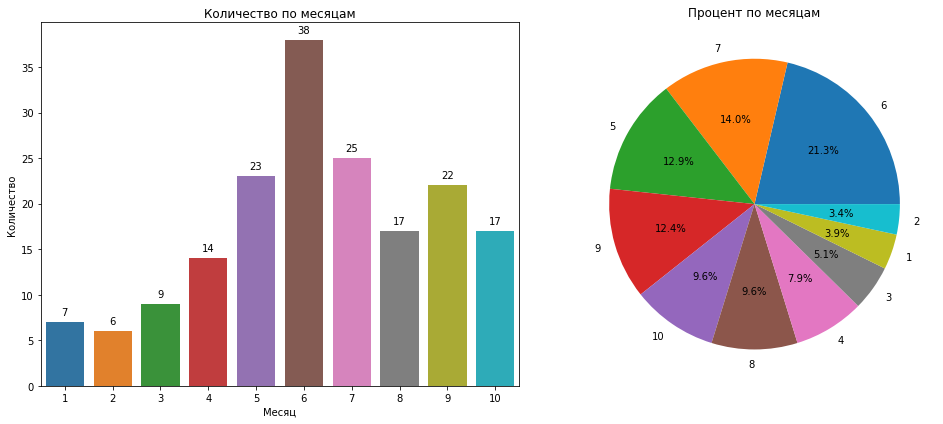

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(
    data=freq_table_parmezan_month,
    x='Месяц',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по месяцам')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_parmezan_month['percent'],
    labels=freq_table_parmezan_month['Месяц'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по месяцам')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [48]:
freq_table_parmezan_quarter = parmezan_sales.stb.freq(['Квартал'])
freq_table_parmezan_quarter

,Квартал,count,percent,cumulative_count,cumulative_percent
0,2,75,42.13,75,42.13
1,3,64,35.96,139,78.09
2,1,22,12.36,161,90.45
3,4,17,9.55,178,100.00


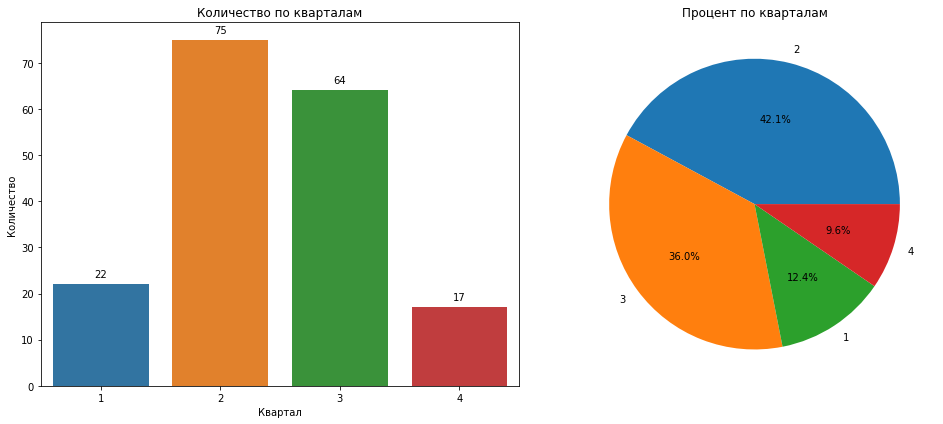

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(
    data=freq_table_parmezan_quarter,
    x='Квартал',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по кварталам')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_parmezan_quarter['percent'],
    labels=freq_table_parmezan_quarter['Квартал'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по кварталам')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [50]:
freq_table_parmezan_distribution_channel = parmezan_sales.stb.freq(['Канал сбыта'])
freq_table_parmezan_distribution_channel

,Канал сбыта,count,percent,cumulative_count,cumulative_percent
0,1.1 Дистрибьюторы,79,44.38,79,44.38
1,1.2.3 Фокусные клиенты,69,38.76,148,83.15
2,1.2.1 Региональные партнеры,16,8.99,164,92.13
3,1.3.1 Ключевой оптовик,6,3.37,170,95.51
4,1.2.2 МСК партнеры,5,2.81,175,98.31
5,2.2 Региональные сети,2,1.12,177,99.44
6,1.7 Экспорт,1,0.56,178,100.00


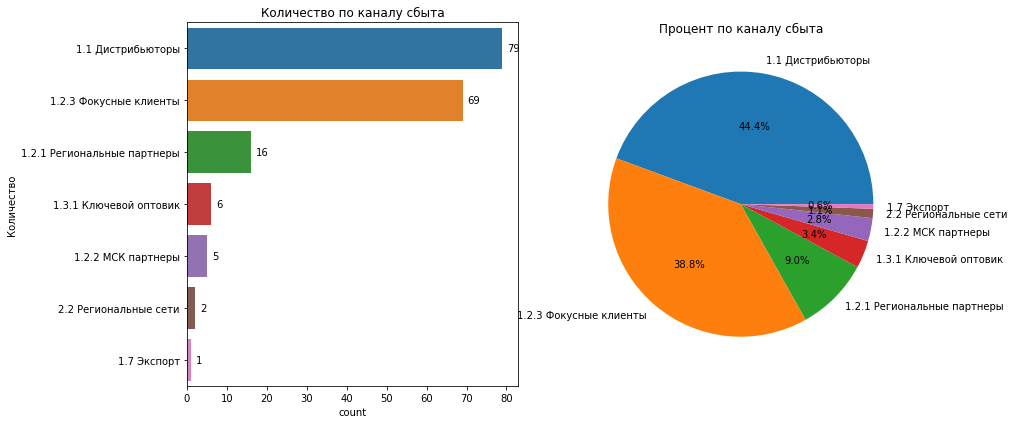

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(
    data=freq_table_parmezan_distribution_channel,
    x='count', 
    y='Канал сбыта',
    ax=axes[0]
)
axes[0].set_title('Количество по каналу сбыта')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
    
    
    
    
axes[1].pie(
    freq_table_parmezan_distribution_channel['percent'],
    labels=freq_table_parmezan_distribution_channel['Канал сбыта'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по каналу сбыта')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [52]:
parmezan_sales.stb.freq(['Публичное наименование нормализованное'])

,Публичное наименование нормализованное,count,percent,cumulative_count,cumulative_percent
0,ПАРМЕЗАН,178,100.00,178,100.00


In [53]:
freq_table_parmezan_managers = parmezan_sales.stb.freq(['Менеджер'])
freq_table_parmezan_managers

,Менеджер,count,percent,cumulative_count,cumulative_percent
0,Света,74,41.57,74,41.57
1,Саша,58,32.58,132,74.16
2,Виктория,36,20.22,168,94.38
3,Ольга,8,4.49,176,98.88
4,Таня,2,1.12,178,100.00


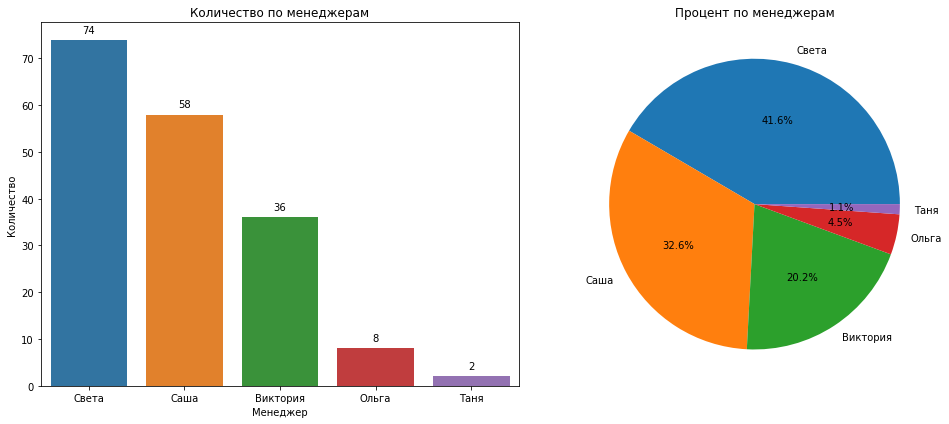

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.barplot(
    data=freq_table_parmezan_managers,
    x='Менеджер',
    y='count',
    ax=axes[0]
)
axes[0].set_title('Количество по менеджерам')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=5)
    
axes[1].pie(
    freq_table_parmezan_managers['percent'],
    labels=freq_table_parmezan_managers['Менеджер'],
    autopct='%1.1f%%'
)
axes[1].set_title('Процент по менеджерам')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [55]:
parmezan_sales.stb.freq(['Годен до'])

,Годен до,count,percent,cumulative_count,cumulative_percent
0,23.11.2025,38,21.35,38,21.35
1,30.12.2025,25,14.04,63,35.39
2,27.10.2025,23,12.92,86,48.31
3,11.02.2026,22,12.36,108,60.67
4,13.01.2026,17,9.55,125,70.22
5,01.03.2026,17,9.55,142,79.78
6,08.09.2025,14,7.87,156,87.64
7,17.08.2025,9,5.06,165,92.70
8,18.07.2025,7,3.93,172,96.63
9,23.08.2025,6,3.37,178,100.00


In [56]:
parmezan_sales.stb.freq(['Срок годности'])

,Срок годности,count,percent,cumulative_count,cumulative_percent
0,211,178,100.00,178,100.00


In [57]:
parmezan_sales['Годен до'] = pd.to_datetime(parmezan_sales['Годен до'])


In [58]:
parmezan_sales

,Месяц,Квартал,Канал сбыта,Публичное наименование нормализованное,Вес,Менеджер,Годен до,Срок годности
0,1,1,1.1 Дистрибьюторы,ПАРМЕЗАН,452.56,Саша,2025-07-18,211
1,1,1,1.2.3 Фокусные клиенты,ПАРМЕЗАН,703.13,Саша,2025-07-18,211
2,1,1,1.1 Дистрибьюторы,ПАРМЕЗАН,308.74,Виктория,2025-07-18,211
3,2,1,1.3.1 Ключевой оптовик,ПАРМЕЗАН,352.02,Саша,2025-08-23,211
4,2,1,1.1 Дистрибьюторы,ПАРМЕЗАН,112.61,Света,2025-08-23,211
...,...,...,...,...,...,...,...,...
173,8,3,1.2.2 МСК партнеры,ПАРМЕЗАН,532.32,Ольга,2026-01-13,211
174,9,3,1.1 Дистрибьюторы,ПАРМЕЗАН,303.39,Саша,2026-11-02,211
175,9,3,1.1 Дистрибьюторы,ПАРМЕЗАН,2013.88,Света,2026-11-02,211
176,10,4,1.3.1 Ключевой оптовик,ПАРМЕЗАН,742.00,Ольга,2026-01-03,211


Выводы по 'ПАРМЕЗАН ПРОДАЖИ_отпр.xlsx':
1. Наблюдается ярко выраженная сезонность. Стратегию продвижения и планирование запасов необходимо выстраивать с учетом пиковых нагрузок в середине года.

2. Света, несмотря на низкие общие показатели, является ключевым специалистом по продажам пармезана. Уход Светы может привести к катастрофическому падению продаж именно этой позиции. Необходимо закрепить за ней функции наставника для других менеджеров по данному продукту, чтобы снизить зависимость.